## 1. Reading, cleaning & splitting

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

# reading
url = "https://drive.google.com/file/d/1qjVXQDkmYlnMPFFx8pTTeAQuH646KVWu/view?usp=share_link"
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
data = df = pd.read_csv(path)

# X and y creation
X = data.drop(columns=["PoolArea",'MiscFeature','Fence','PoolQC'])
y = X.pop("Expensive")

# Feature Engineering
#X.loc[:, "Cabin"] = X.Cabin.str[0]

# data splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

data

,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,8450,65.0,856,3,0,0,2,0,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,9600,80.0,1262,3,1,0,2,298,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,11250,68.0,920,3,1,0,2,0,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,9550,60.0,756,3,1,0,3,0,0,0,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,14260,84.0,1145,4,1,0,3,192,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,7917,62.0,953,3,1,0,2,0,0,0,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1456,13175,85.0,1542,3,2,0,2,349,0,0,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1457,9042,66.0,1152,4,2,0,1,0,0,1,...,Attchd,RFn,TA,TA,Y,NaN,GdPrv,Shed,WD,Normal
1458,9717,68.0,1078,2,0,0,1,366,0,0,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal


## 2. Building the `preprocessor`

We have included all the code to create the preprocessing pipeline in a single cell for compactness. Take your time to understand what's going on. If needed, create multiple cells and bring the code there step by step, analyzing the output each time. Writing a sketch of the pipeline with pen an paper is also a good idea.

In [13]:
# 1. defining categorical & ordinal columns
X_cat = X.select_dtypes(exclude="number").copy()
X_num = X.select_dtypes(include="number").copy()

# 2. numerical pipeline
numeric_pipe = make_pipeline(
    SimpleImputer(strategy="mean"))

# # 3. categorical pipeline
# # 3.1 defining ordinal & onehot columns
# ordinal_cols = X_cat.columns.get_indexer(["Cabin"])
# onehot_cols = X_cat.columns.get_indexer(["Sex", "Embarked"])

# # 3.2. defining the categorical encoder
# # 3.2.1. we manually establish the order of the categories for our ordinal feature (Cabin), including "N_A"
# cabin_cats = ["A", "B", "C", "D", "E", "F", "G", "T", "N_A"]
# # 3.2.2. defining the categorical encoder: a ColumnTransformer with 2 branches: ordinal & onehot
# categorical_encoder = ColumnTransformer(
#     transformers=[
#         ("cat_ordinal", OrdinalEncoder(categories=[cabin_cats]), ordinal_cols),
#         ("cat_onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols),
#     ]
# )

# # 3.3. categorical pipeline = "N_A" imputer + categorical encoder
# categorical_pipe = make_pipeline(
#     SimpleImputer(strategy="constant", fill_value="N_A"),
#     categorical_encoder
# )

 # 3 create categorical pipeline, with the SimpleImputer(fill_value="N_A") and the OneHotEncoder
categorical_pipe = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="N_A"),
    OneHotEncoder(sparse_output=False, handle_unknown='ignore')
)

# 4. full preprocessing: a ColumnTransformer with 2 branches: numeric & categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num_pipe", numeric_pipe, X_num.columns),
        ("cat_pipe", categorical_pipe, X_cat.columns),
    ]
)

In [14]:
# 5.1 Creating the full_pipeline (preprocessor + Decision Tree)
full_pipeline = make_pipeline(preprocessor, 
                              DecisionTreeClassifier()).set_output(transform='pandas')

# 5.2 fit this full_pipeline to the 
full_pipeline.fit(X_train, y_train)

# 5.3 make predictions
full_pipeline.predict(X_train)

array([1, 0, 1, ..., 1, 0, 0])

## 3. Decision Tree

In [15]:
from sklearn.model_selection import GridSearchCV

# full pipeline: preprocessor + model
full_pipeline = make_pipeline(preprocessor, 
                              DecisionTreeClassifier())#.set_output(transform='pandas')

# define parameter grid
param_grid = {
    "columntransformer__num_pipe__simpleimputer__strategy":["mean", "median"],
    "decisiontreeclassifier__max_depth": range(2, 14, 2),
    "decisiontreeclassifier__min_samples_leaf": range(3, 12, 2)
}

# define GridSearchCV
search = GridSearchCV(full_pipeline,
                      param_grid,
                      cv=7,
                      verbose=0)

search.fit(X_train, y_train)
 
scores = {"dtree" : search.best_score_}

scores

{'dtree': 0.9263555505168665}

## 4. Error analysis

In [16]:
accuracy_score(search.predict(X_test), y_test)

0.934931506849315

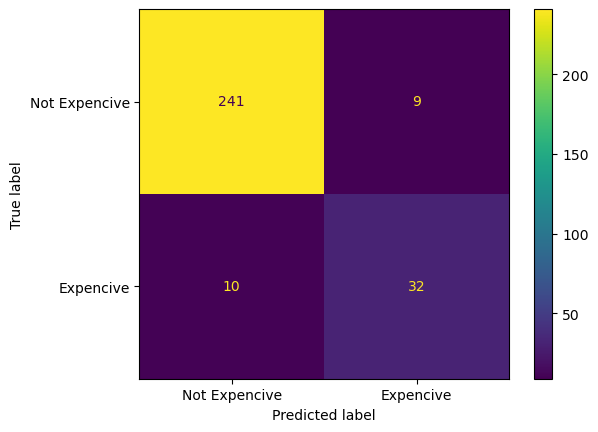

In [17]:
#from sklearn.metrics import plot_confusion_matrix
#plot_confusion_matrix(search, X_test, y_test, display_labels=['Not Survied', 'Survived']);

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(search, 
                                      X_test, 
                                      y_test, 
                                      display_labels=['Not Expencive', 'Expencive']);

## 5. KNN

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

knn_full_pipeline = make_pipeline(preprocessor,
                                  StandardScaler(),
                                  KNeighborsClassifier()
                                 )

In [19]:

from sklearn.model_selection import GridSearchCV

param_grid = {
    "columntransformer__num_pipe__simpleimputer__strategy":["mean", "median"],
    "kneighborsclassifier__n_neighbors": range(2, 50, 2),
    "kneighborsclassifier__weights": ["uniform", "distance"],
    "standardscaler__with_std":[True, False]
}

knn_search = GridSearchCV(knn_full_pipeline,
                      param_grid,
                      cv=7,
                      verbose=0)

knn_search.fit(X_train, y_train)

scores["knn"] = knn_search.best_score_

scores

{'dtree': 0.9263555505168665, 'knn': 0.9281024869366259}

In [20]:
knn_search.best_params_

{'columntransformer__num_pipe__simpleimputer__strategy': 'mean',
 'kneighborsclassifier__n_neighbors': 6,
 'kneighborsclassifier__weights': 'distance',
 'standardscaler__with_std': True}